<a href="https://colab.research.google.com/github/Lanaanvar/Deep-Learning/blob/main/PPCA_and_ICA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PPCA for Image Recontstruction

PCA Reconstruction Error: 0.1972
PPCA Reconstruction Error: 0.4872


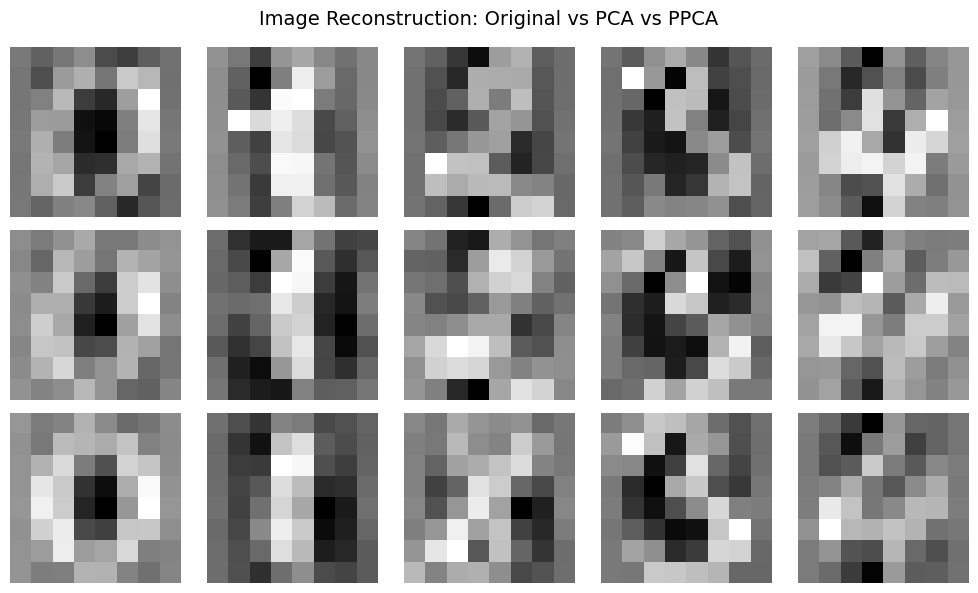

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture

# Load MNIST-like dataset (digits)
data = load_digits()
X = StandardScaler().fit_transform(data.data)

# PCA for comparison
pca = PCA(n_components=20)
X_pca = pca.fit_transform(X)
X_recon_pca = pca.inverse_transform(X_pca)

# PPCA approximation using GaussianMixture (note: not true PPCA)
gmm = GaussianMixture(n_components=20, covariance_type='full', random_state=0)
gmm.fit(X)
X_recon_ppca = gmm.means_[gmm.predict(X)]

# Compare reconstruction
mse_pca = np.mean((X - X_recon_pca)**2)
mse_ppca = np.mean((X - X_recon_ppca)**2)

print(f"PCA Reconstruction Error: {mse_pca:.4f}")
print(f"PPCA Reconstruction Error: {mse_ppca:.4f}")

# Plot: Original (top), PCA reconstruction (middle), PPCA reconstruction (bottom)
plt.figure(figsize=(10, 6))
for i in range(5):
    # Original
    plt.subplot(3, 5, i + 1)
    plt.imshow(X[i].reshape(8, 8), cmap='gray')
    plt.axis('off')
    if i == 0:
        plt.ylabel("Original", fontsize=12)

    # PCA
    plt.subplot(3, 5, i + 6)
    plt.imshow(X_recon_pca[i].reshape(8, 8), cmap='gray')
    plt.axis('off')
    if i == 0:
        plt.ylabel("PCA", fontsize=12)

    # PPCA
    plt.subplot(3, 5, i + 11)
    plt.imshow(X_recon_ppca[i].reshape(8, 8), cmap='gray')
    plt.axis('off')
    if i == 0:
        plt.ylabel("PPCA", fontsize=12)

plt.suptitle("Image Reconstruction: Original vs PCA vs PPCA", fontsize=14)
plt.tight_layout()
plt.show()


# PPCA for missing data

Missing values: 9.84%
MSE on imputed (missing) values: 0.20802


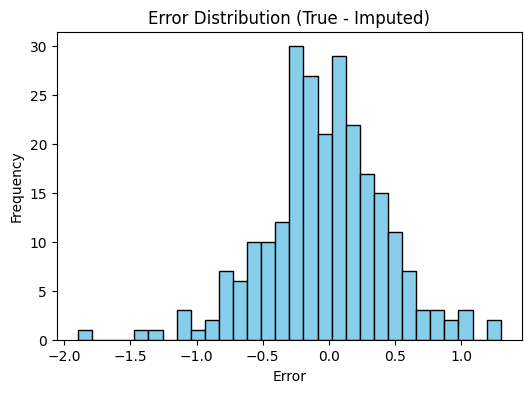

In [18]:
import numpy as np
from numpy.linalg import inv
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# --- I. Create Synthetic Data ---
np.random.seed(42)
n_samples, n_features, latent_dim = 500, 5, 2

# latent variables
Z = np.random.randn(n_samples, latent_dim)

# loading matrix
W_true = np.random.randn(n_features, latent_dim)

# noise
sigma2_true = 0.1
X_true = Z @ W_true.T + np.sqrt(sigma2_true) * np.random.randn(n_samples, n_features)

# introduce 10% missing values
X_missing = X_true.copy()
missing_mask = np.random.rand(*X_missing.shape) < 0.1
X_missing[missing_mask] = np.nan

print(f"Missing values: {np.mean(missing_mask)*100:.2f}%")

# --- II. PPCA via EM Algorithm ---
def ppca_em(X, latent_dim, max_iter=100, tol=1e-4):
    n_samples, n_features = X.shape
    # initialize W, sigma2, mu
    mu = np.nanmean(X, axis=0)
    X_centered = X - mu
    X_centered[np.isnan(X_centered)] = 0
    W = np.random.randn(n_features, latent_dim)
    sigma2 = 1.0

    for iteration in range(max_iter):
        W_old = W.copy()

        M = W.T @ W + sigma2 * np.eye(latent_dim)
        M_inv = inv(M)
        Ez = np.zeros((n_samples, latent_dim))
        Ezz = np.zeros((latent_dim, latent_dim))

        # --- E-step ---
        X_filled = X_centered.copy()
        for i in range(n_samples):
            obs = ~np.isnan(X[i])
            Wo = W[obs, :]
            xo = X_centered[i, obs]
            Mo_inv = inv(Wo.T @ Wo + sigma2 * np.eye(latent_dim))
            Ez[i] = Mo_inv @ Wo.T @ xo
            Ezz += sigma2 * Mo_inv + np.outer(Ez[i], Ez[i])

            # Fill missing values (for reconstruction)
            miss = np.isnan(X[i])
            if np.any(miss):
                X_filled[i, miss] = (W[miss, :] @ Ez[i])

        # --- M-step ---
        W = (X_filled.T @ Ez) @ inv(Ezz)
        sigma2 = np.sum((X_filled - Ez @ W.T)**2) / (n_samples * n_features)
        sigma2 = max(sigma2, 1e-6)

        # convergence check
        if np.linalg.norm(W - W_old) < tol:
            break

    # reconstruct full data
    X_recon = Ez @ W.T + mu
    return X_recon, W, sigma2

# --- Run PPCA ---
X_imputed, W_est, sigma2_est = ppca_em(X_missing, latent_dim=latent_dim)

# --- III. Compare with True Values ---
mse = mean_squared_error(X_true[missing_mask], X_imputed[missing_mask])
print(f"MSE on imputed (missing) values: {mse:.5f}")

plt.figure(figsize=(6,4))
plt.hist(X_true[missing_mask] - X_imputed[missing_mask], bins=30, color='skyblue', edgecolor='black')
plt.title("Error Distribution (True - Imputed)")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()


# ICA

Audio files not found, generating synthetic signals instead.
Correlation between separated and true sources:
 [[ 0.056  0.997]
 [ 0.998 -0.072]]


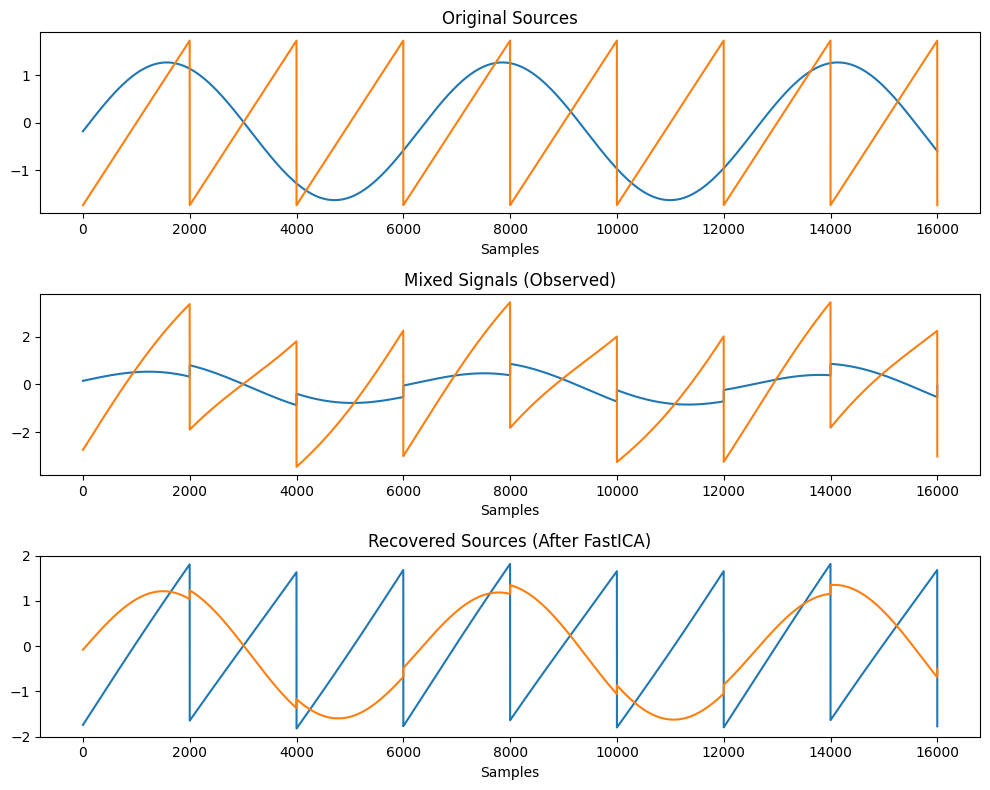

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import FastICA
from scipy.io import wavfile
from scipy import signal

# --- 1. Download / Load Audio Files ---
# You can replace these with your own .wav files
# Example: speech.wav, music.wav
# For demonstration, we'll generate synthetic signals if you don’t have files.

try:
    rate1, s1 = wavfile.read('speech.wav')
    rate2, s2 = wavfile.read('music.wav')
    s1 = s1.astype(float)
    s2 = s2.astype(float)
    rate = min(rate1, rate2)
    min_len = min(len(s1), len(s2))
    S = np.c_[s1[:min_len], s2[:min_len]]
except FileNotFoundError:
    # Synthetic fallback: two signals (sine and sawtooth)
    print("Audio files not found, generating synthetic signals instead.")
    rate = 2000
    t = np.linspace(0, 8, rate * 8)
    s1 = np.sin(2 * t)  # Sine wave
    s2 = signal.sawtooth(2 * np.pi * t)  # Sawtooth
    S = np.c_[s1, s2]

# Standardize signals
S -= S.mean(axis=0)
S /= S.std(axis=0)

# --- 2. Create Mixed Signals ---
np.random.seed(42)
A = np.random.randn(2, 2)  # random mixing matrix
X = S @ A.T  # mixed signals

# --- 3. Apply FastICA ---
ica = FastICA(n_components=2, random_state=42)
S_ = ica.fit_transform(X)  # separated signals
A_est = ica.mixing_

# --- 4. Compare with Original Using Correlation ---
corr_matrix = np.corrcoef(S_.T, S.T)[:2, 2:]
print("Correlation between separated and true sources:\n", np.round(corr_matrix, 3))

# --- 5. Plot Waveforms ---
fig, axes = plt.subplots(3, 1, figsize=(10, 8))
axes[0].plot(S)
axes[0].set_title("Original Sources")
axes[1].plot(X)
axes[1].set_title("Mixed Signals (Observed)")
axes[2].plot(S_)
axes[2].set_title("Recovered Sources (After FastICA)")
for ax in axes: ax.set_xlabel("Samples")
plt.tight_layout()
plt.show()
